# MNIST Handwritten Digit Classification

This notebook demonstrates how to build a simple neural network for classifying handwritten digits (0-9) from the MNIST dataset using TensorFlow and Keras. The MNIST dataset contains 70,000 grayscale images of handwritten digits, each 28x28 pixels.

## Overview

This project covers:
- Loading and exploring the MNIST dataset
- Data preprocessing (normalization)
- Building a neural network model
- Training and evaluating the model
- Making predictions and visualizing results

## Requirements

Make sure you have the following packages installed:
- TensorFlow 2.x
- NumPy
- Matplotlib
- Scikit-learn (for confusion matrix)

You can install them using: `pip install -r requirements.txt`

In [25]:
!pip install tensorflow matplotlib numpy

In [26]:
!pip install pydot graphviz

## Setup and Dependencies

Install the required packages if not already installed. This step ensures all necessary libraries are available.

In [27]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

## Loading the MNIST Dataset

The MNIST dataset is a classic dataset for handwritten digit recognition. It consists of 60,000 training images and 10,000 test images of digits from 0 to 9.

In [28]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

## Data Exploration and Visualization

Let's explore the dataset by visualizing some sample images and understanding the data structure.

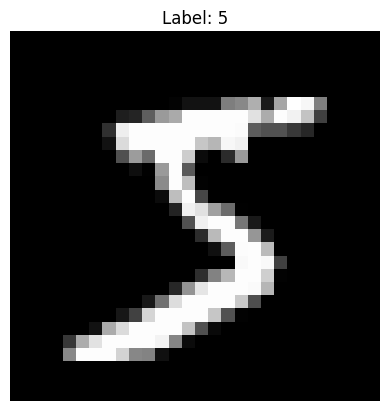

In [29]:
#visualize images
plt.imshow(x_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

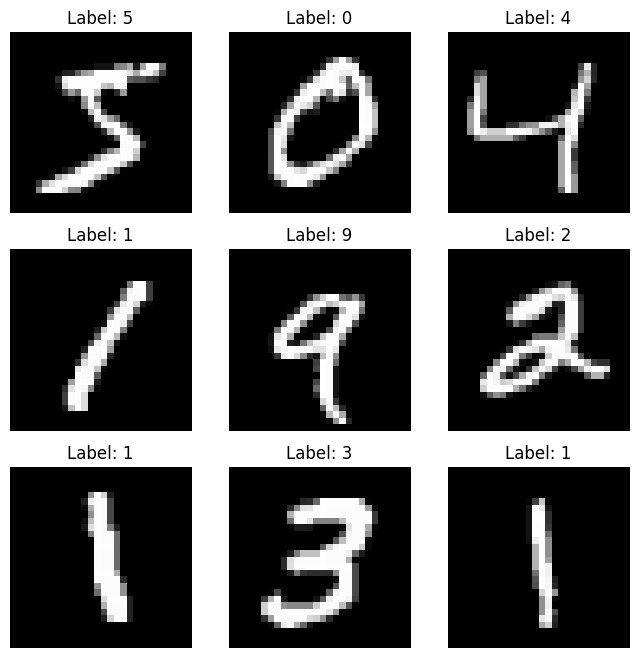

In [30]:
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.show()

In [31]:
print(x_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


In [32]:
print(x_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

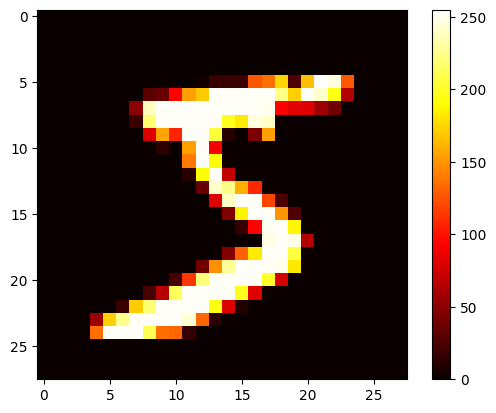

In [33]:
plt.imshow(x_train[0], cmap='hot')
plt.colorbar()
plt.show()


In [34]:
#NORMALIZING THE DATASET
x_train = x_train / 255.0
x_test = x_test / 255.0

## Data Preprocessing

Neural networks perform better with normalized data. We scale the pixel values from 0-255 to 0-1.

In [35]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Building the Neural Network Model

We create a simple feedforward neural network with:
- An input layer that flattens the 28x28 images into 784 pixels
- A hidden layer with 128 neurons and ReLU activation
- An output layer with 10 neurons (one for each digit) and softmax activation

In [36]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## Model Visualization

Let's visualize the architecture of our neural network.

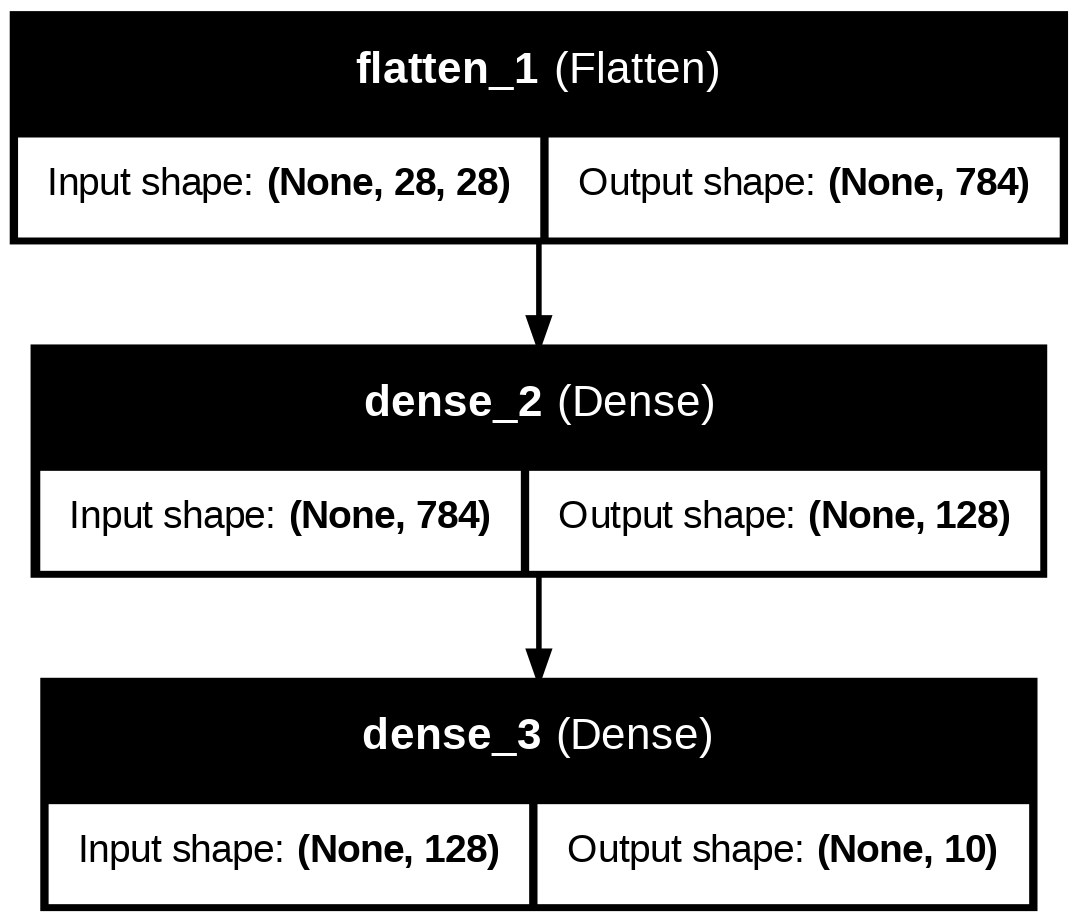

In [37]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file="neural_network.png",
    show_shapes=True,
    show_layer_names=True
)

In [38]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Training the Model

We compile the model with:
- Adam optimizer for efficient gradient descent
- Sparse categorical crossentropy loss (suitable for integer labels)
- Accuracy as the evaluation metric

Then train the model for 30 epochs with validation on the test set.

In [39]:
history = model.fit(
    x_train,
    y_train,
    epochs=30,
    validation_data=(x_test, y_test)
)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9281 - loss: 0.2553 - val_accuracy: 0.9591 - val_loss: 0.1345
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9667 - loss: 0.1121 - val_accuracy: 0.9716 - val_loss: 0.0950
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9768 - loss: 0.0771 - val_accuracy: 0.9739 - val_loss: 0.0859
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9816 - loss: 0.0602 - val_accuracy: 0.9734 - val_loss: 0.0857
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9855 - loss: 0.0469 - val_accuracy: 0.9756 - val_loss: 0.0824
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9883 - loss: 0.0372 - val_accuracy: 0.9757 - val_loss: 0.0788
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9905 - loss: 0.0309 - val_accuracy: 0.9737 - val_loss: 0.0909
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9923 - loss: 0.0245 -

## Training Results and Visualization

After training, we plot the loss and accuracy curves for both training and validation sets to monitor overfitting and convergence.

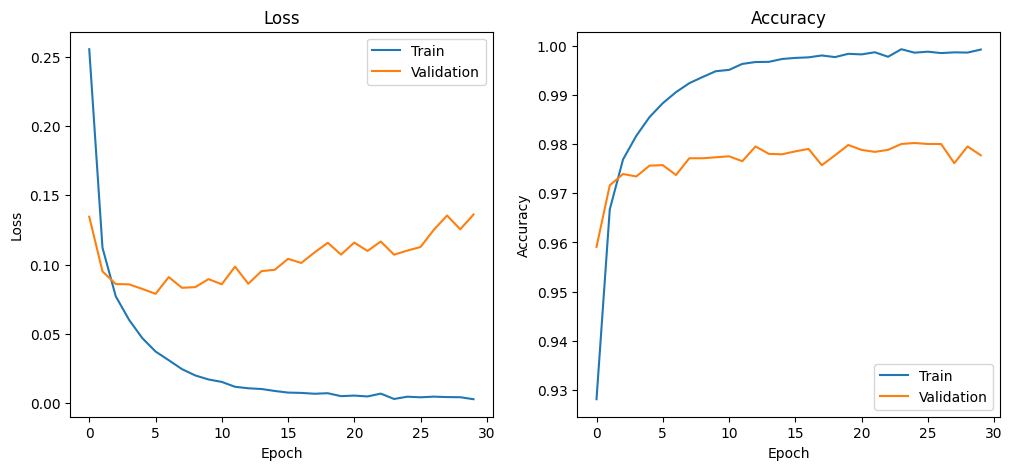

In [43]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

In [44]:
#Test Model
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9777 - loss: 0.1361
Test Accuracy: 0.9776999950408936


## Model Evaluation

Evaluate the trained model on the test set to get the final accuracy and loss.

In [45]:
#Making a Prediction
predictions = model.predict(x_test)

print(np.argmax(predictions[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
7


## Making Predictions

Use the trained model to make predictions on test images. The model outputs probabilities for each digit class.

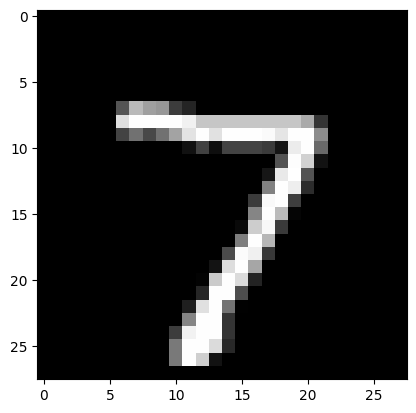

In [46]:
#image to show
plt.imshow(x_test[0], cmap='gray')
plt.show()

In [47]:
import numpy as np

predictions = model.predict(x_test)

y_pred = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [48]:
!pip install scikit-learn

In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 971    0    0    1    1    0    2    1    3    1]
 [   0 1118    3    2    1    1    3    2    4    1]
 [   4    3  993   10    5    0    0    5   12    0]
 [   0    0    2  996    0    3    0    2    0    7]
 [   1    0    2    0  963    0    2    0    1   13]
 [   2    1    0   13    0  862    3    1    7    3]
 [   6    3    2    1    4    4  933    1    3    1]
 [   1    2    6    0    2    0    0 1006    2    9]
 [   3    0    2    8    4    4    0    6  941    6]
 [   1    2    0    1    4    1    0    6    0  994]]


## Confusion Matrix Analysis

A confusion matrix shows the model's predictions versus the actual labels. It helps identify which digits are most commonly misclassified.

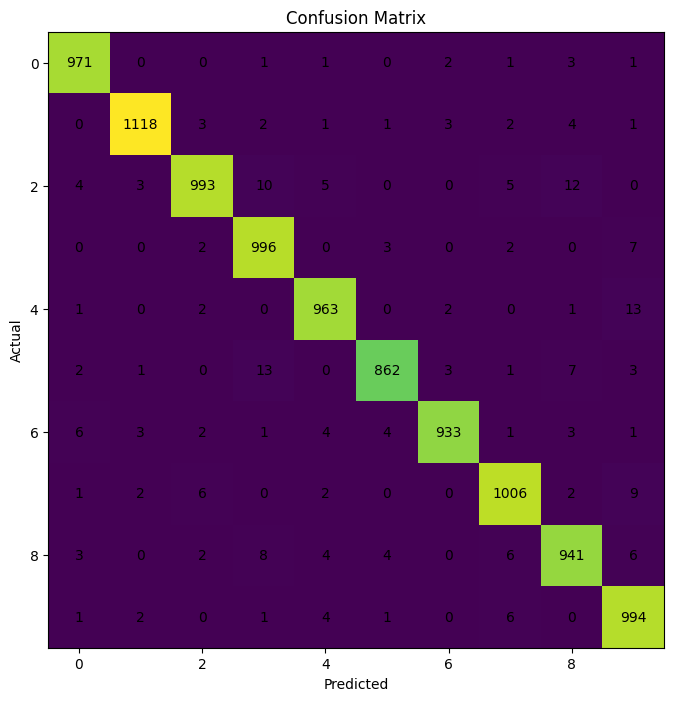

In [51]:
plt.figure(figsize=(8,8))
plt.imshow(cm)

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()